# Simulated Data
### For N stocks and T days
### Randomly generate a covariance matrix $C$ of size $N \times N$
### Simulate daily returns using this covariance matrix
### Estimate the covariance matrix from the simulated returns
### Compare the estimated covariance matrix $E$ and actual covariance matrix $C$
### Check the claim : $(1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})$

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

Number of stocks : N =  500
Number of days : T =  2500
operator_norm(C) =  0.9990262246371092
frobenius_norm(C) =  13.068125331246698
operator_norm(S) =  0.9990262246371097
frobenius_norm(S) =  13.068125331246698
basic stats for eig_vals:
shape : (500,)
min : 0.003436704525507237
max : 0.9990262246371097
sum : 251.44955032842427
mean : 0.5028991006568485
std : 0.2977319161676761
Sanity check : operator_norm(Q @ Q.T - identity_N) =  2.7370173575881936e-15
Sanity check : frobenius_norm(Q @ Q.T - identity_N) =  2.371733536522995e-14
Z.shape =  (2500, 500)
R.shape =  (2500, 500)
basic stats for daily returns
shape : (2500, 500)
min : -3.264801270924522
max : 3.462484944801874
sum : -855.2002942123092
mean : -0.0006841602353698474
std : 0.7085561212178706


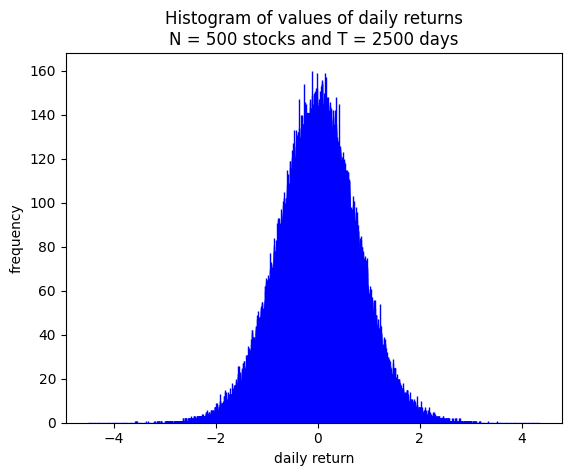

E.shape =  (500, 500)
operator_norm(E) =  1.4787284446079678
operator_norm(C) =  0.9990262246371092
frobenius_norm(E) =  13.97261769080913
frobenius_norm(C) =  13.068125331246698
q =  0.2
Trace(C^{-1}) =  2950.647914006023
Trace(E^{-1}) =  3651.1807429031414
Sanity check (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})
(1.0 - q) * Trace(E^{-1}) =  2920.9445943225132 , Trace(C^{-1}) =  2950.647914006023 , error =  0.010117722928097862
operator_norm( (1.0 - q) * E^{-1} ) =  282.32952941163853
operator_norm( C^{-1} ) =  290.9764259854147
Sanity check : operator_norm( (1.0 - q) * E^{-1} - C^{-1} ) = 23.66933192658969
frobenius_norm( (1.0 - q) * E^{-1} ) =  390.0703163875699
frobenius_norm( C^{-1} ) =  395.5105578889464
Sanity check : frobenius_norm( (1.0 - q) * E^{-1} - C^{-1} ) = 64.7462908129417


In [10]:
N = 500 # number of stocks
T = 2500 # number of days

print("Number of stocks : N = ", N)
print("Number of days : T = ", T)

C, Q, S, eig_vals = generate_covariance_matrix(N)

print("operator_norm(C) = ", operator_norm(C))
print("frobenius_norm(C) = ", frobenius_norm(C)) 
print("operator_norm(S) = ", operator_norm(S))
print("frobenius_norm(S) = ", frobenius_norm(S))

print("basic stats for eig_vals:")
display_stats(eig_vals)

# N * N identity matrix
identity_N = np.identity(N)

# check that Q is orthogonal
print("Sanity check : operator_norm(Q @ Q.T - identity_N) = ", operator_norm(Q @ Q.T - identity_N))
print("Sanity check : frobenius_norm(Q @ Q.T - identity_N) = ", frobenius_norm(Q @ Q.T - identity_N))

sqrt_eig_vals = this_vec_sqrt(eig_vals)
sqrt_S = np.diag(sqrt_eig_vals)

# generate a random array of size T * N, with independent N(0,1) entries
mean = 0
std_dev = 1
shape = (T,N)
Z = np.random.normal(loc=mean, scale=std_dev, size=shape)
print("Z.shape = ", Z.shape)

# generate the (un-normalised) T * N matrix of random returns
# column i is the returns to stock i
R = Z @ sqrt_S @ Q.T
print("R.shape = ", R.shape)

print("basic stats for daily returns")
display_stats(R)

this_title = "Histogram of values of daily returns\n"
this_title += "N = " + str(N) + " stocks and T = " + str(T) + " days"
plot_histogram(X, x_label = "daily return", y_label = "frequency", hist_title = this_title)

# normalise
X = (1.0 / math.sqrt(T)) * R

# estimate the covariance matrix
E = X.T @ X
print("E.shape = ", E.shape)
print("operator_norm(E) = ", operator_norm(E))
print("operator_norm(C) = ", operator_norm(C))
print("frobenius_norm(E) = ", frobenius_norm(E))
print("frobenius_norm(C) = ", frobenius_norm(C))

# aspect ratio
q = N/T
print("q = ", q)

# sanity check the claim : (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})
C_inv = np.linalg.inv(C)
trace_C_inv = np.trace(C_inv)
print("Trace(C^{-1}) = ", trace_C_inv)

E_inv = np.linalg.inv(E)
rescale_E_inv = (1.0 - q) * E_inv
trace_E_inv = np.trace(E_inv)
print("Trace(E^{-1}) = ", trace_E_inv)

print("Sanity check (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})")
lhs = (1.0 - q) * trace_E_inv
rhs = trace_C_inv
print("(1.0 - q) * Trace(E^{-1}) = ", lhs, ", Trace(C^{-1}) = ", rhs, ", error = ", abs(math.log(lhs/rhs)))

print("operator_norm( (1.0 - q) * E^{-1} ) = ", operator_norm(rescale_E_inv))
print("operator_norm( C^{-1} ) = ", operator_norm(C_inv))
print("Sanity check : operator_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", operator_norm(rescale_E_inv - C_inv))

print("frobenius_norm( (1.0 - q) * E^{-1} ) = ", frobenius_norm(rescale_E_inv))
print("frobenius_norm( C^{-1} ) = ", frobenius_norm(C_inv))
print("Sanity check : frobenius_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", frobenius_norm(rescale_E_inv - C_inv))

In [2]:
# apply sqrt to an array by vectorisation
def this_sqrt(x):
  return math.sqrt(max(x,0.0))

# Apply the function using np.vectorize
this_vec_sqrt = np.vectorize(this_sqrt)

In [3]:
def generate_covariance_matrix(N : int, min_eig_val : float = 0.001) -> tuple:

    # generate an orthogonal N * N matrix
    Q = generate_orthogonal_matrix(N)

    # generate non-negative eigenvalues 
    # drawn independently from a uniform U[min_eig_val,1] distribution
    # we use [min_eig_val, 1.0] to prevent blow-ups for C^{-1}
    eig_vals = np.random.uniform(low = min_eig_val, high = 1, size = N) # generate non-negative

    # define the diagonal matrix S
    S = np.diag(eig_vals)

    # generate the covariance matrix
    covariance_matrix = Q @ S @ Q.T

    return covariance_matrix, Q, S, eig_vals

In [4]:
def generate_orthogonal_matrix(N : int) -> np.ndarray:
  """
  generate an orthogonal matrix of dimension N, using the QR decomposition. 
  """
  
  H = np.random.randn(N, N)
  Q, R = np.linalg.qr(H)
  Q *= np.sign(np.diag(R)) # Ensure positive diagonal
  return Q

In [5]:
def operator_norm(A : np.ndarray) -> float:
    """
    calculate the operator norm of an N * N matrix A
    as sqrt(lambda_max)
    where lambda_max is the largest (most positive) eigenvalue of A.T @ A
    """

    # calculate A.T @ A
    ATA = A.T @ A

    # calculate the eignevalues and eigenvectors
    eig_vals, eig_vecs = np.linalg.eig(ATA)

    # get the max eigenvalue
    lambda_max = np.max(eig_vals)

    # calculate the operator norm
    operator_norm = math.sqrt(lambda_max)

    return operator_norm

In [6]:
def frobenius_norm(A : np.ndarray) -> float:
    """
    calculate the Frobenius norm of a matrix A
    as sqrt(Trace(A.T @ A))
    """
    # calculate A.T @ A
    ATA = A.T @ A

    # calculate the trace
    trATA = np.trace(ATA)

    # calculate the frobenius norm as the sqrt of the trace
    frobenius_norm = math.sqrt(trATA)

    return frobenius_norm

In [7]:
def display_stats(this_array : np.ndarray):
    """
    print basic stats for a numpy array
    """
    
    print("shape :", this_array.shape)
    print("min :", np.min(this_array))
    print("max :", np.max(this_array))
    print("sum :", np.sum(this_array))
    print("mean :", np.mean(this_array))
    print("std :", np.std(this_array))
    return

In [8]:
def plot_histogram(this_array : np.ndarray,  
                   x_label : str = "x_label", 
                   y_label : str = "y_label",
                   hist_title : str = "hist_title",
                   num_bins : int = 100,
                   rescale_factor : float = 1.0, 
                   verbose : bool = False
                  ):

    """
    plot a histogram of the values of a numpy array
    """
    
    custom_bins = []
    this_min = np.min(this_array)
    this_max = np.max(this_array)
    this_mid = 0.5 * (this_min + this_max)
    min_value = this_mid + 1.25 * rescale_factor * (this_min - this_mid)
    max_value = this_mid + 1.25 * rescale_factor * (this_max - this_mid)
    step_size = (max_value - min_value) / num_bins
    for i in range(num_bins + 1):
        custom_bins.append(min_value + i * step_size)
    
    # Compute histogram with custom bins
    hist, bin_edges = np.histogram(this_array, bins=custom_bins)

    if verbose:
        print("Histogram counts:", hist)

    plt.hist(this_array, bins=custom_bins, edgecolor='blue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(hist_title)
    plt.show()